In [147]:
import numpy as numpy
import pandas as pd

In [148]:
df = pd.read_csv('spam.csv', encoding="latin-1")


In [149]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1976,ham,Lol alright i was thinkin that too haha,NaN,NaN,NaN
2616,ham,I went to ur hon lab but no one is there.,NaN,NaN,NaN
4130,ham,\Its Ur luck to Love someone. Its Ur fortune t...,its a miracle to Love a person who can't Love...,NaN,NaN
3354,ham,Minimum walk is 3miles a day.,NaN,NaN,NaN
4040,spam,Please call our customer service representativ...,NaN,NaN,NaN


steps 
1- Data Cleaning
2- EDA
3 - Text processing
4 - Model building
5 - Evaluation
6 - Improvement
7 - Website
8 - Deploy

# Data Cleaning

In [150]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [151]:
# drop Last 3 columns
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [152]:
df.sample(5)

,v1,v2
1233,ham,Lol ok. I'll snatch her purse too.
508,ham,What's the significance?
5031,ham,Ok i vl..do u know i got adsense approved..
115,ham,"As I entered my cabin my PA said, '' Happy B'd..."
4713,ham,Oops i thk i dun haf enuff... I go check then ...


In [153]:

# rename the columns
df.rename(columns={'v1':'ID','v2':'TEXT'}, inplace=True)
df.sample(5)

,ID,TEXT
4332,ham,Y bishan lei... I tot Ì_ say lavender?
5532,ham,happened here while you were adventuring
3533,ham,Good evening! How are you?
716,spam,+449071512431 URGENT! This is the 2nd attempt ...
77,ham,I like you peoples very much:) but am very shy...


In [154]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [155]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['ID']=encoder.fit_transform(df['ID'])


In [156]:
df.head()

,ID,TEXT
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [157]:
#missing values
df.isnull().sum()

ID      0
TEXT    0
dtype: int64

In [158]:
# check for the duplicate values
df.duplicated().sum()

np.int64(403)

In [159]:
# remove duplicates
df = df.drop_duplicates(keep='first')

In [160]:
df.duplicated().sum()

np.int64(0)

In [161]:
df.shape

(5169, 2)

# 2 EDA

In [162]:
df.head()

,ID,TEXT
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [163]:
df['ID'].value_counts()

ID
0    4516
1     653
Name: count, dtype: int64

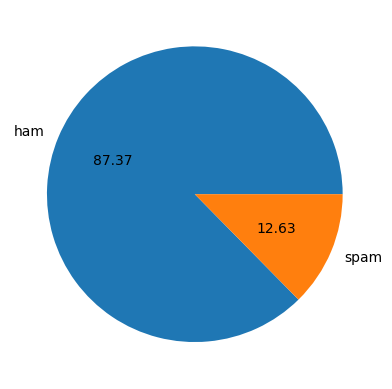

In [164]:
import matplotlib.pyplot as plt
plt.pie(df['ID'].value_counts(), labels=['ham','spam'], autopct="%0.2f")
plt.show()

In [165]:
import nltk

print(nltk.data.path)

['/Users/krishna/nltk_data', '/Library/Frameworks/Python.framework/Versions/3.14/nltk_data', '/Library/Frameworks/Python.framework/Versions/3.14/share/nltk_data', '/Library/Frameworks/Python.framework/Versions/3.14/lib/nltk_data', '/usr/share/nltk_data', '/usr/local/share/nltk_data', '/usr/lib/nltk_data', '/usr/local/lib/nltk_data']


In [166]:
df['num_characters']=df['TEXT'].apply(len)


In [167]:
df.head()

,ID,TEXT,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [168]:
df['num_words']=df['TEXT'].apply(lambda x:len(nltk.word_tokenize(x))) # braeking the message word by words

In [169]:
df.head()

,ID,TEXT,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [170]:
df['num_sentences']=df['TEXT'].apply(lambda x:len(nltk.sent_tokenize(x))) # braeking the message sentence by sen
                                                                         # len() giving the number of the sentences
df.head()                                                                         

,ID,TEXT,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [171]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.460437,1.965564
std,58.236293,13.334441,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [172]:
# Ham 
df[df['ID'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.128432,1.820195
std,56.358207,13.504730,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [173]:
# Spam
df[df['ID'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.672282,2.970904
std,30.137753,7.010932,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [174]:
# histogram
import seaborn as sns


<Axes: xlabel='num_characters', ylabel='Count'>

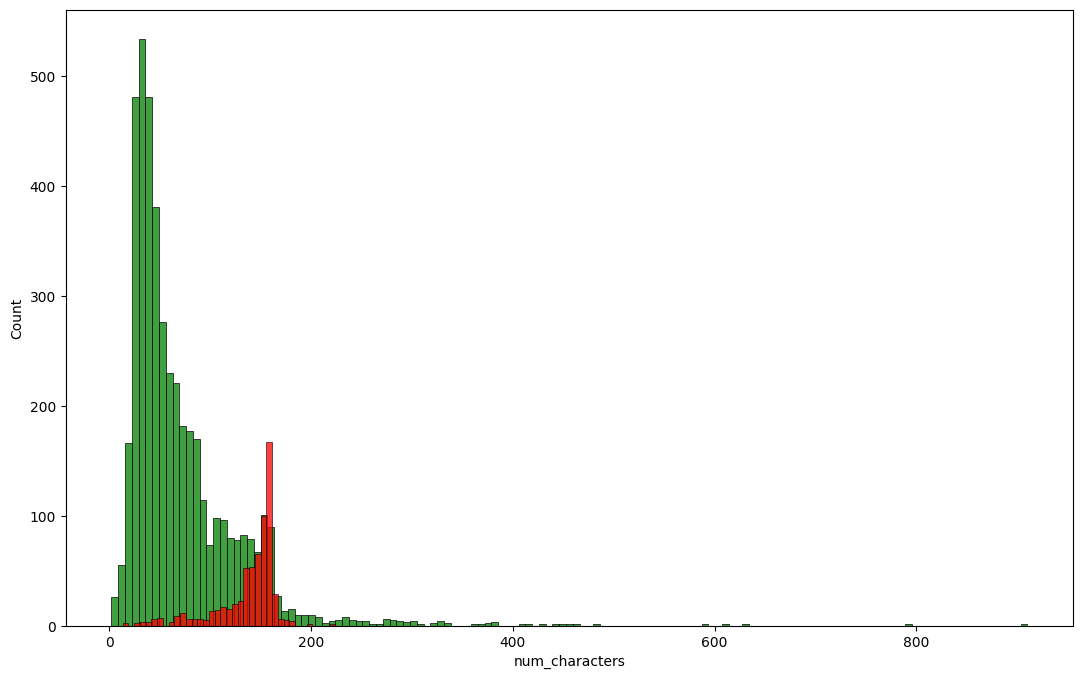

In [175]:
plt.figure(figsize=(13,8))
sns.histplot(df[df['ID'] == 0]['num_characters'],color='green')
sns.histplot(df[df['ID'] == 1]['num_characters'],color='red')


<Axes: xlabel='num_words', ylabel='Count'>

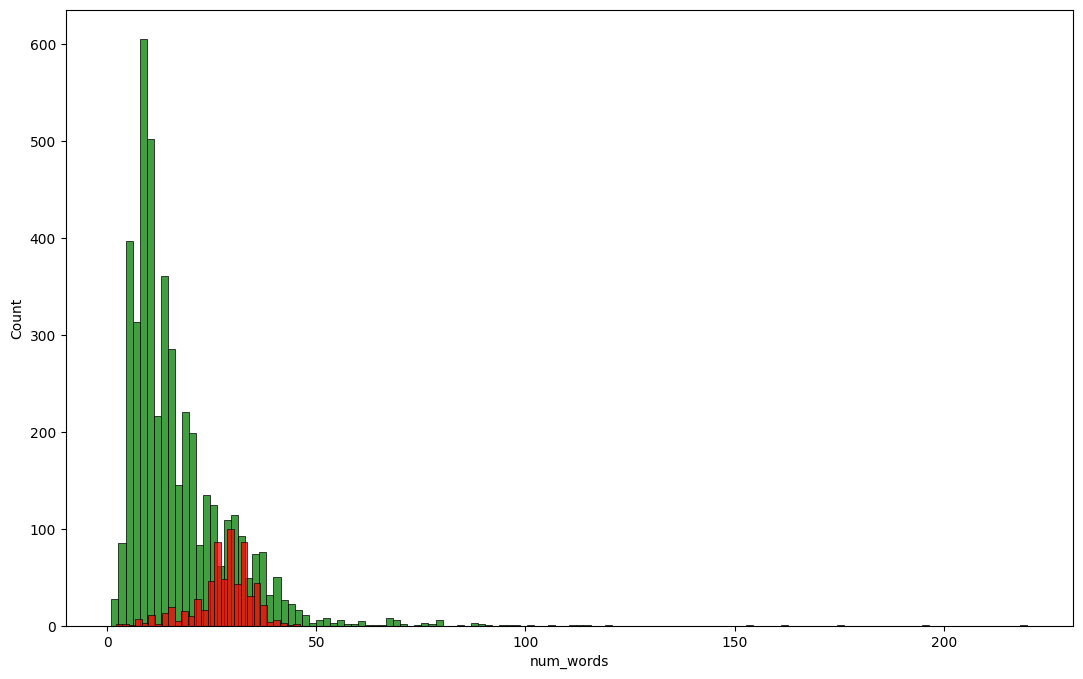

In [176]:
plt.figure(figsize=(13,8))
sns.histplot(df[df['ID'] == 0]['num_words'],color='green')
sns.histplot(df[df['ID'] == 1]['num_words'],color='red')


<Axes: xlabel='num_sentences', ylabel='Count'>

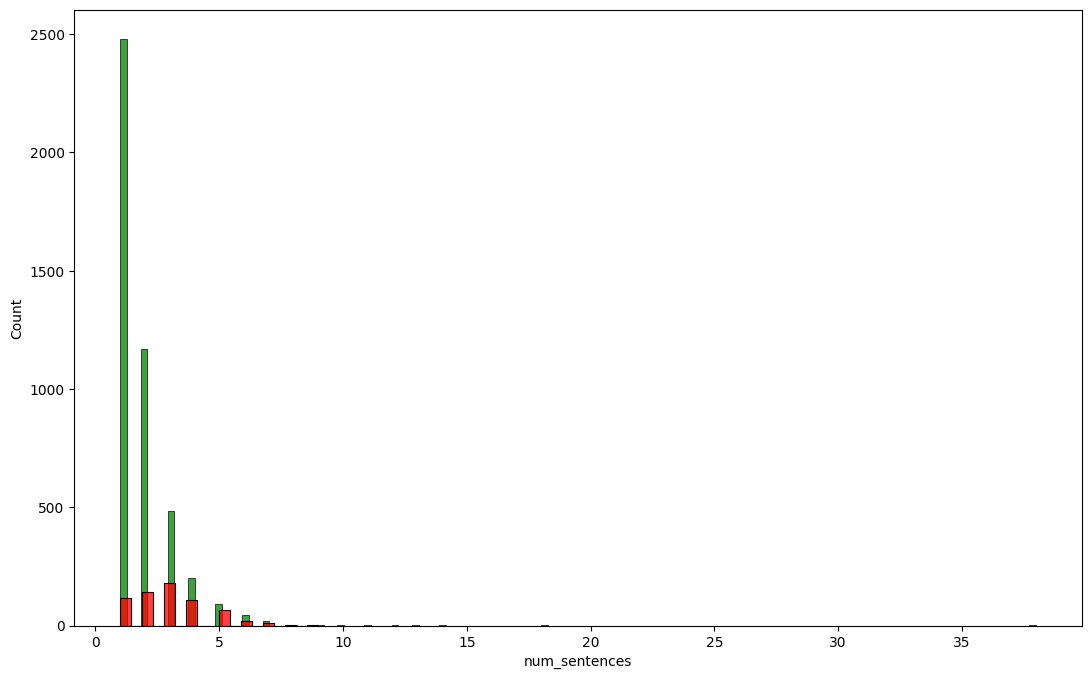

In [177]:
plt.figure(figsize=(13,8))
sns.histplot(df[df['ID'] == 0]['num_sentences'],color='green')
sns.histplot(df[df['ID'] == 1]['num_sentences'],color='red')


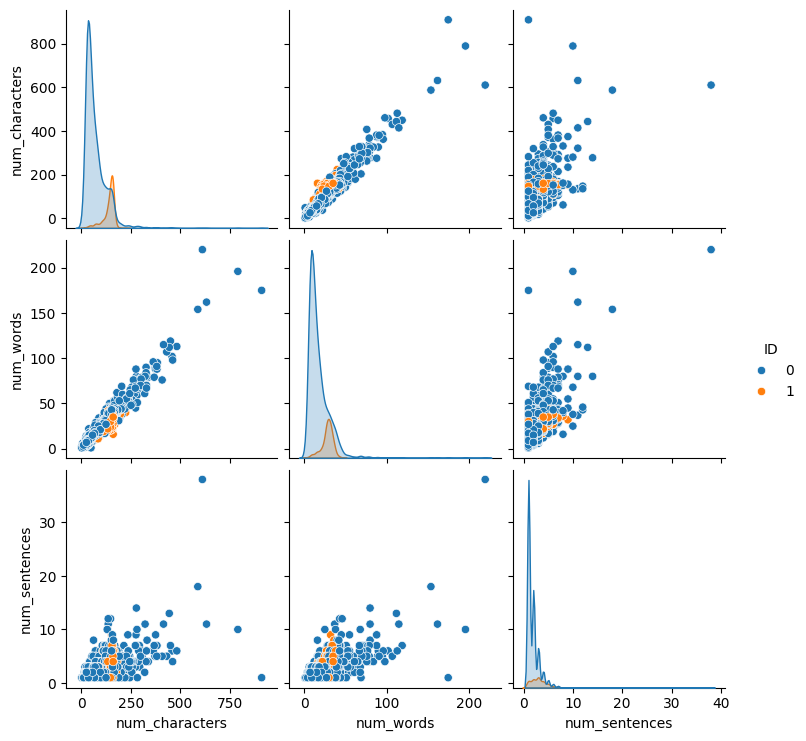

In [178]:
sns.pairplot(df,hue="ID")


<Axes: >

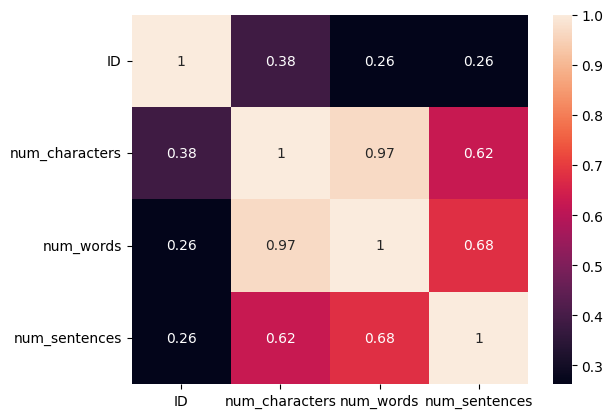

In [179]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# 3. Data Preprocessing

In [227]:
def transform_text(text):
    text = text.lower() # transform the each words into lower case
    text = nltk.word_tokenize(text) # word tokenization
    # checking for the alphanumeric
    y =[]
    for i in text:
        if i.isalnum(): #removing the special characters
            
            y.append(i)
            
    text = y[:] #clonning
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)      
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
   
    return " ".join(y)

In [235]:
transform_text('I\'m gonna be home soon and i don\'t want to talk about this stuff anymore tonight, k? I\'ve cried enough today.')


'gon na home soon want talk stuff anymor tonight k cri enough today'

In [234]:
df['TEXT'][10]


"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [238]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('Coding')

'code'

In [247]:
df['transformed_text']=df["TEXT"].apply(transform_text)

In [240]:
df.head()

,ID,TEXT,num_characters,num_words,num_sentences,transforned_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


# wordcloud

In [253]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500, min_font_size=10, background_color = 'white')

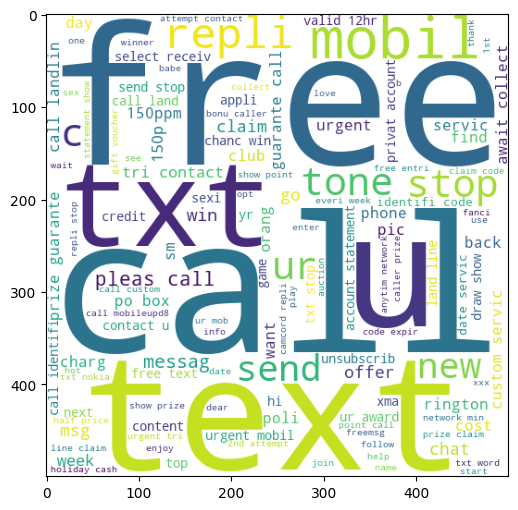

In [258]:
spam_wc=wc.generate(df[df['ID'] == 1]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize=(12,6))

plt.imshow(spam_wc)

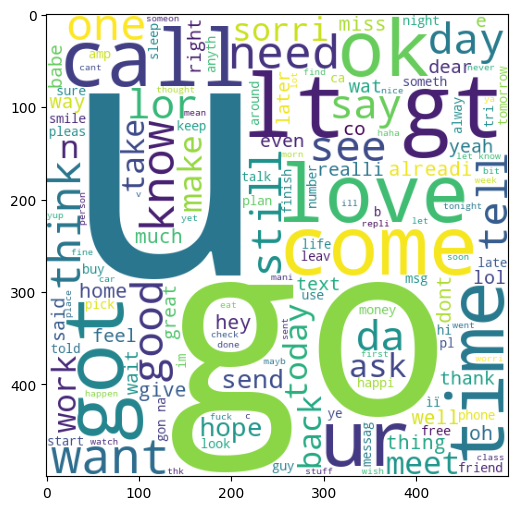

In [259]:
ham_wc=wc.generate(df[df['ID'] == 0]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize=(12,6))

plt.imshow(ham_wc)